# Liver Stiffness Measurement (LSM) Analysis: NHANES 2017–18 and 2021–22

NHANES added transient elastography (FibroScan) to the exam protocol in 2017–18 (cycle J)
and continued it in 2021–22 (cycle L). These are the only two NHANES cycles with direct
liver stiffness measurement (LSM, kPa) alongside the controlled attenuation parameter
(CAP, dB/m) for steatosis.

**This notebook:**
1. Downloads the 2021–22 NHANES data (LUX, DEMO, BIOPRO, CBC, BMX, SMQ)
2. Computes LSM- and FIB-4-based fibrosis categories for both cycles
3. Analyses age/sex/race-stratified LSM distributions (cross-sectional)
4. Extracts limited pseudo-cohort signal from the two LSM cycles (4-year gap)
5. Compares FIB-4 and LSM concordance
6. Notes what additional signal EPIC Cosmos data could provide

**LSM thresholds used (Castera/EASL):**

| Category | LSM (kPa) | Fibrosis stage |
|----------|-----------|----------------|
| Low (F0–F1) | < 7.1 | None–mild |
| Intermediate | 7.1–9.4 | Significant |
| High (F3–F4) | ≥ 9.5 | Severe–cirrhosis |

In [1]:
import os, warnings
import requests
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 6)
sns.set_style('whitegrid')

DATA_DIR   = os.path.abspath(os.path.join('..', 'data'))
RAW_NHANES = os.path.join(DATA_DIR, 'raw', 'nhanes')
DERIVED    = os.path.join(DATA_DIR, 'derived')

# Castera/EASL LSM thresholds
LSM_F01   = 7.1   # below this: F0-F1
LSM_F34   = 9.5   # at or above this: F3-F4

# FIB-4 thresholds
FIB4_LOW  = 1.30
FIB4_HIGH = 2.67

RACE_MAP = {1: 'Mexican American', 2: 'Other Hispanic',
            3: 'Non-Hispanic White', 4: 'Non-Hispanic Black', 5: 'Other/Multi-Racial'}

print('Setup complete')

Setup complete


## 1. Download and prepare 2021–22 data

In [2]:
def download(url, dest):
    if os.path.exists(dest):
        return dest
    print(f'  GET {url}')
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        f.write(r.content)
    print(f'    -> {os.path.basename(dest)} ({len(r.content):,} bytes)')
    return dest

def read_xpt(path):
    try:
        df, _ = pyreadstat.read_xport(path)
    except UnicodeDecodeError:
        df, _ = pyreadstat.read_xport(path, encoding='latin1')
    return df

NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public'

# 2021-22: suffix L, year 2021; BPX renamed to BPXO
CYCLE_2122 = {
    'year': 2021, 'suffix': 'L', 'cycle': '2021-2022',
    'files': ['DEMO', 'BIOPRO', 'CBC', 'BMX', 'BPXO', 'TRIGLY', 'GLU', 'SMQ', 'LUX'],
}

cdir = os.path.join(RAW_NHANES, '2021_2022')
os.makedirs(cdir, exist_ok=True)

raw_2122 = {}
for name in CYCLE_2122['files']:
    fname = f"{name}_{CYCLE_2122['suffix']}.xpt"
    url   = f"{NHANES_BASE}/{CYCLE_2122['year']}/DataFiles/{fname}"
    path  = download(url, os.path.join(cdir, fname))
    raw_2122[name] = read_xpt(path)
    print(f'  {name}: {len(raw_2122[name]):,} rows, cols: {list(raw_2122[name].columns[:6])} ...')

print('\n2021-22 data loaded.')

  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt


    -> DEMO_L.xpt (2,582,160 bytes)
  DEMO: 11,933 rows, cols: ['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BIOPRO_L.xpt


    -> BIOPRO_L.xpt (2,425,520 bytes)
  BIOPRO: 7,199 rows, cols: ['SEQN', 'WTPH2YR', 'LBXSATSI', 'LBXSAL', 'LBDSALSI', 'LBXSAPSI'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/CBC_L.xpt


    -> CBC_L.xpt (1,609,840 bytes)
  CBC: 8,727 rows, cols: ['SEQN', 'WTPH2YR', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.xpt


    -> BMX_L.xpt (1,563,200 bytes)
  BMX: 8,860 rows, cols: ['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.xpt


    -> BPXO_L.xpt (696,720 bytes)
  BPXO: 7,801 rows, cols: ['SEQN', 'BPAOARM', 'BPAOCSZ', 'BPXOSY1', 'BPXODI1', 'BPXOSY2'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TRIGLY_L.xpt


    -> TRIGLY_L.xpt (321,840 bytes)
  TRIGLY: 3,996 rows, cols: ['SEQN', 'WTSAF2YR', 'LBXTLG', 'LBDTRSI', 'LBDLDL', 'LBDLDLSI'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/GLU_L.xpt


    -> GLU_L.xpt (129,200 bytes)
  GLU: 3,996 rows, cols: ['SEQN', 'WTSAF2YR', 'LBXGLU', 'LBDGLUSI'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SMQ_L.xpt


    -> SMQ_L.xpt (651,120 bytes)
  SMQ: 9,015 rows, cols: ['SEQN', 'SMQ020', 'SMQ040', 'SMD641', 'SMD650', 'SMD100MN'] ...
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/LUX_L.xpt


    -> LUX_L.xpt (765,680 bytes)
  LUX: 7,199 rows, cols: ['SEQN', 'LUAXSTAT', 'LUARXNC', 'LUARXND', 'LUARXIN', 'LUAPNME'] ...

2021-22 data loaded.


In [3]:
def build_lsm_dataset(raw_d, cycle_label, has_bpxo=False):
    """Merge NHANES components into an analytic LSM dataset."""
    df = raw_d['DEMO'].copy()

    # AST, ALT
    bdf = raw_d['BIOPRO']
    ast_col = next((c for c in ['LBXSASSI','LBXSAS'] if c in bdf.columns), None)
    alt_col = next((c for c in ['LBXSATSI','LBXSAT'] if c in bdf.columns), None)
    df = df.merge(bdf[['SEQN', ast_col, alt_col]].rename(
        columns={ast_col:'AST', alt_col:'ALT'}), on='SEQN', how='left')

    # Platelets
    cdf = raw_d['CBC']
    plt_col = next((c for c in ['LBXPLTSI','LBXPLT'] if c in cdf.columns), None)
    df = df.merge(cdf[['SEQN', plt_col]].rename(
        columns={plt_col:'PLATELETS'}), on='SEQN', how='left')

    # BMI
    df = df.merge(raw_d['BMX'][['SEQN','BMXBMI']], on='SEQN', how='left')

    # Blood pressure (BPXSY1 in J; BPXOSY1 in L)
    bpx_key = 'BPXO' if has_bpxo else 'BPX'
    if bpx_key in raw_d:
        bpx = raw_d[bpx_key]
        sy_cols = [c for c in bpx.columns if 'SY' in c and c.startswith('BPX')]
        if sy_cols:
            bpx = bpx[['SEQN'] + sy_cols].copy()
            bpx['SBP_MEAN'] = bpx[sy_cols].mean(axis=1)
            df = df.merge(bpx[['SEQN','SBP_MEAN']], on='SEQN', how='left')
        else:
            df['SBP_MEAN'] = np.nan
    else:
        df['SBP_MEAN'] = np.nan

    # Smoking
    smq = raw_d['SMQ'][['SEQN','SMQ020']].copy()
    smq['SMOKE_EVER'] = smq['SMQ020'].map({1: 1.0, 2: 0.0})
    df = df.merge(smq[['SEQN','SMOKE_EVER']], on='SEQN', how='left')

    # LSM and CAP
    lux = raw_d['LUX'][['SEQN','LUXSMED','LUXCAPM','LUXSIQR']].rename(
        columns={'LUXSMED':'LSM_KPA','LUXCAPM':'CAP_DBM','LUXSIQR':'LSM_IQR'})
    df = df.merge(lux, on='SEQN', how='left')

    # Filter eligible adults ≥ 18
    df = df[df['RIDSTATR'] == 2].copy()   # both interview + exam
    df['AGE']    = df['RIDAGEYR']
    df = df[df['AGE'] >= 18].copy()
    df['FEMALE'] = (df['RIAGENDR'] == 2).astype(float)
    df['SEX']    = df['FEMALE'].map({0:'Male', 1:'Female'})
    df['RACE']   = df['RIDRETH1'].map(RACE_MAP)
    df['CYCLE']  = cycle_label

    # FIB-4
    mask = (df['AST'] > 0) & (df['ALT'] > 0) & (df['PLATELETS'] > 0) & (df['AGE'] >= 35)
    df.loc[mask, 'FIB4'] = (
        df.loc[mask, 'AGE'] * df.loc[mask, 'AST'] /
        (df.loc[mask, 'PLATELETS'] * np.sqrt(df.loc[mask, 'ALT']))
    )

    # LSM category (Castera/EASL)
    df['LSM_CAT'] = pd.cut(
        df['LSM_KPA'],
        bins=[0, LSM_F01, LSM_F34, np.inf],
        labels=['Low F0-F1 (<7.1)', 'Intermediate (7.1-9.4)', 'High F3-F4 (≥9.5)']
    )

    # IQR/median ratio (reliability indicator; >0.30 suggests unreliable)
    df['LSM_IQR_RATIO'] = df['LSM_IQR'] / df['LSM_KPA']

    n = len(df)
    lsm_n = df['LSM_KPA'].notna().sum()
    fib4_n = df['FIB4'].notna().sum()
    print(f'{cycle_label}: {n:,} eligible adults | LSM: {lsm_n:,} ({lsm_n/n*100:.0f}%) | FIB-4: {fib4_n:,}')
    return df


# Load 2017-18 from existing parquet (already has LSM_KPA merged in)
df_j = pd.read_parquet(os.path.join(DERIVED, '2017_2018.parquet'))
df_j['CYCLE'] = '2017-2018'
df_j['SEX']   = df_j['FEMALE'].map({0:'Male', 1:'Female'})
df_j['RACE']  = df_j['RIDRETH1'].map(RACE_MAP)
mask = (df_j['AST'] > 0) & (df_j['ALT'] > 0) & (df_j['PLATELETS'] > 0) & (df_j['AGE'] >= 35)
df_j.loc[mask, 'FIB4'] = (
    df_j.loc[mask, 'AGE'] * df_j.loc[mask, 'AST'] /
    (df_j.loc[mask, 'PLATELETS'] * np.sqrt(df_j.loc[mask, 'ALT']))
)
df_j['LSM_CAT'] = pd.cut(
    df_j['LSM_KPA'],
    bins=[0, LSM_F01, LSM_F34, np.inf],
    labels=['Low F0-F1 (<7.1)', 'Intermediate (7.1-9.4)', 'High F3-F4 (≥9.5)']
)
df_j['LSM_IQR_RATIO'] = df_j.get('LSM_IQR', np.nan)  # may not be in parquet
lsm_n = df_j['LSM_KPA'].notna().sum(); n = len(df_j)
fib4_n = df_j['FIB4'].notna().sum()
print(f'2017-2018: {n:,} eligible adults | LSM: {lsm_n:,} ({lsm_n/n*100:.0f}%) | FIB-4: {fib4_n:,}')

# Build 2021-22
df_l = build_lsm_dataset(raw_2122, '2021-2022', has_bpxo=True)

# Combined dataset for cross-sectional analysis
common_cols = ['SEQN','AGE','SEX','FEMALE','RACE','BMXBMI','CYCLE',
               'AST','ALT','PLATELETS','FIB4','LSM_KPA','CAP_DBM','LSM_IQR_RATIO','LSM_CAT']
for col in common_cols:
    if col not in df_j.columns:
        df_j[col] = np.nan
    if col not in df_l.columns:
        df_l[col] = np.nan

df_both = pd.concat([df_j[common_cols], df_l[common_cols]], ignore_index=True)
print(f'\nCombined: {len(df_both):,} rows across both cycles')

2017-2018: 5,809 eligible adults | LSM: 5,091 (88%) | FIB-4: 3,771
2021-2022: 6,337 eligible adults | LSM: 5,874 (93%) | FIB-4: 4,429

Combined: 12,146 rows across both cycles


## 2. LSM distributions by age group and sex

In [4]:
# Restrict to valid LSM readings with acceptable IQR/M ratio (≤0.30 or missing)
df_lsm = df_both[
    df_both['LSM_KPA'].notna() &
    (df_both['LSM_KPA'] > 0) &
    ((df_both['LSM_IQR_RATIO'].isna()) | (df_both['LSM_IQR_RATIO'] <= 0.30))
].copy()

print(f'Valid LSM readings (IQR/M ≤ 0.30 or missing): {len(df_lsm):,}')
print(f'  2017-18: {(df_lsm["CYCLE"]=="2017-2018").sum():,}')
print(f'  2021-22: {(df_lsm["CYCLE"]=="2021-2022").sum():,}')

df_lsm['AGE_GROUP'] = pd.cut(df_lsm['AGE'],
    bins=[17,29,39,49,59,69,120],
    labels=['18-29','30-39','40-49','50-59','60-69','70+'])

print('\nMedian LSM (kPa) by age group and sex (both cycles combined):')
tbl = df_lsm.groupby(['AGE_GROUP','SEX'])['LSM_KPA'].agg(['median','mean',
    lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count']).round(2)
tbl.columns = ['median','mean','Q25','Q75','n']
display(tbl)

Valid LSM readings (IQR/M ≤ 0.30 or missing): 10,778
  2017-18: 5,091
  2021-22: 5,687

Median LSM (kPa) by age group and sex (both cycles combined):


median  mean   Q25   Q75     n
AGE_GROUP SEX                                   
18-29     Female    4.50  4.90  3.70  5.40   913
          Male      5.00  5.51  4.10  5.93   912
30-39     Female    4.40  5.30  3.70  5.70   834
          Male      5.10  5.93  4.20  6.20   732
40-49     Female    4.60  5.35  3.80  5.80   776
          Male      5.10  6.60  4.30  6.40   671
50-59     Female    5.10  6.37  4.10  6.70   912
          Male      5.35  7.21  4.40  6.80   778
60-69     Female    4.90  5.96  4.00  6.30  1235
          Male      5.40  7.18  4.40  6.90  1100
70+       Female    5.00  5.83  4.10  6.30   985
          Male      5.50  7.07  4.32  6.90   930

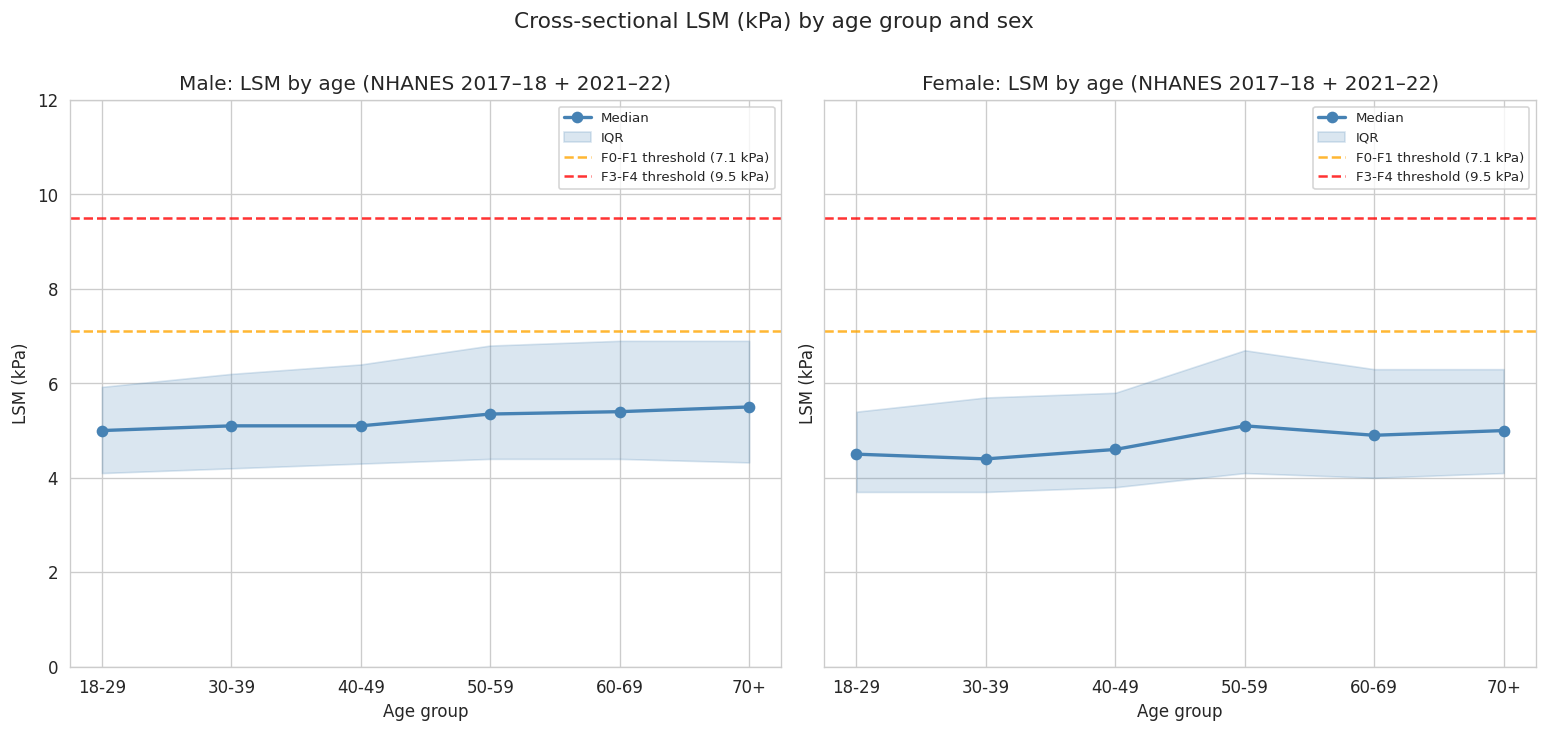

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
age_order = ['18-29','30-39','40-49','50-59','60-69','70+']

for ax, sex in zip(axes, ['Male','Female']):
    sub = df_lsm[df_lsm['SEX']==sex].groupby('AGE_GROUP')['LSM_KPA'].agg(
        median='median', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
    ).reindex(age_order)
    xs = range(len(sub))
    ax.plot(xs, sub['median'], 'o-', color='steelblue', lw=2, label='Median')
    ax.fill_between(xs, sub['q25'], sub['q75'], alpha=0.2, color='steelblue', label='IQR')
    ax.axhline(LSM_F01, color='orange', ls='--', alpha=0.8, label=f'F0-F1 threshold ({LSM_F01} kPa)')
    ax.axhline(LSM_F34, color='red',    ls='--', alpha=0.8, label=f'F3-F4 threshold ({LSM_F34} kPa)')
    ax.set_xticks(xs); ax.set_xticklabels(age_order)
    ax.set_xlabel('Age group'); ax.set_ylabel('LSM (kPa)')
    ax.set_title(f'{sex}: LSM by age (NHANES 2017–18 + 2021–22)')
    ax.legend(fontsize=8); ax.set_ylim(0, 12)

plt.suptitle('Cross-sectional LSM (kPa) by age group and sex', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Prevalence of elevated LSM by age, sex, and race

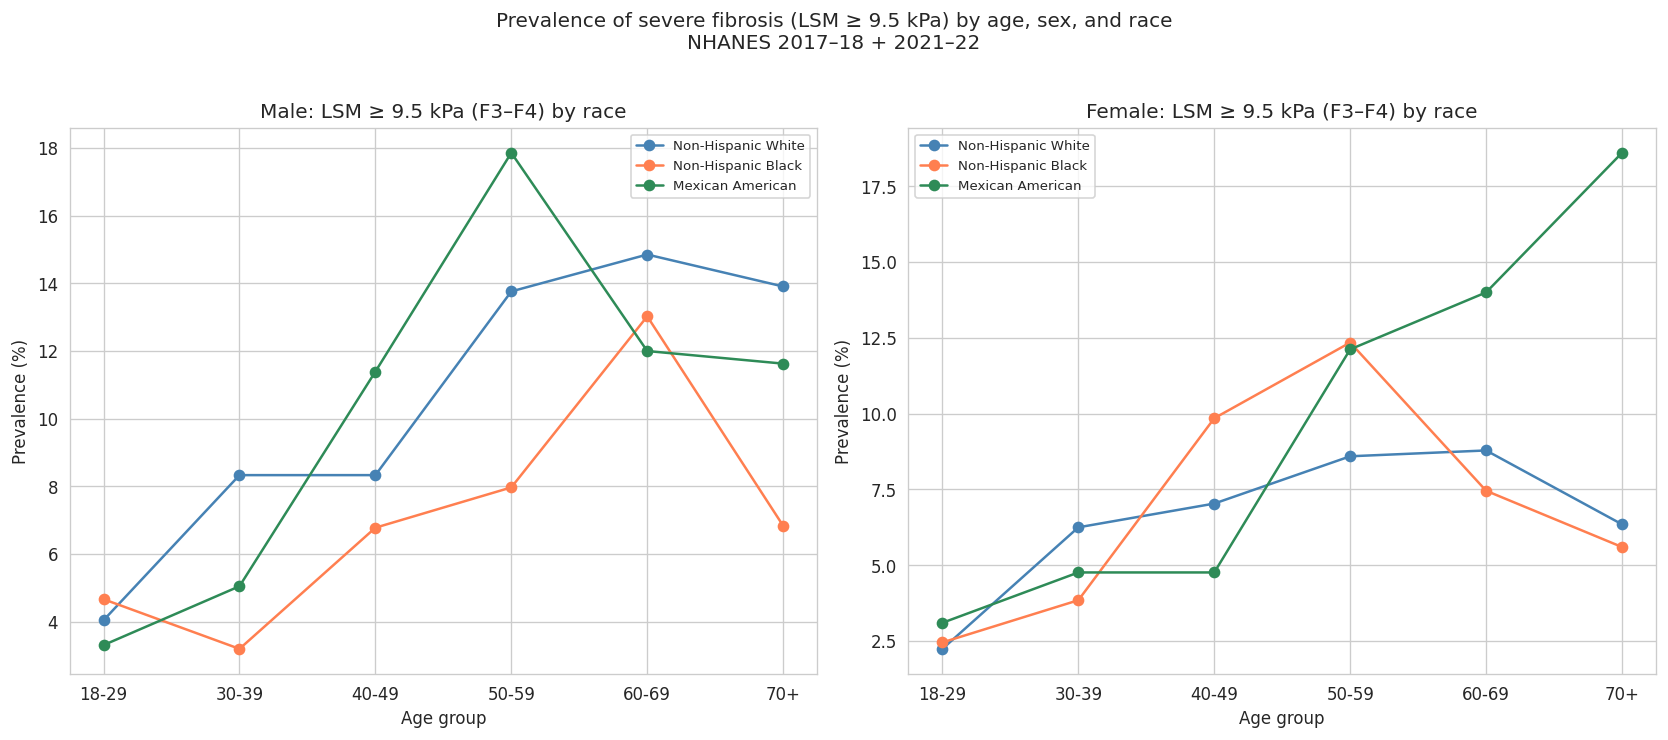

In [6]:
main_races = ['Non-Hispanic White', 'Non-Hispanic Black', 'Mexican American']

prev_lsm = df_lsm.groupby(['AGE_GROUP','SEX','RACE']).apply(
    lambda g: pd.Series({
        'n':          len(g),
        'pct_F34':    (g['LSM_KPA'] >= LSM_F34).mean() * 100,
        'pct_interm': ((g['LSM_KPA'] >= LSM_F01) & (g['LSM_KPA'] < LSM_F34)).mean() * 100,
        'median_lsm': g['LSM_KPA'].median(),
    })
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {'Non-Hispanic White':'steelblue', 'Non-Hispanic Black':'coral', 'Mexican American':'seagreen'}

for ax, sex in zip(axes, ['Male','Female']):
    for race in main_races:
        sub = prev_lsm[(prev_lsm['SEX']==sex) & (prev_lsm['RACE']==race) & (prev_lsm['n']>=20)]
        sub = sub.set_index('AGE_GROUP').reindex(age_order).reset_index()
        ax.plot(range(len(sub)), sub['pct_F34'], 'o-', color=colors[race], label=race)
    ax.set_xticks(range(len(age_order))); ax.set_xticklabels(age_order)
    ax.set_xlabel('Age group'); ax.set_ylabel('Prevalence (%)')
    ax.set_title(f'{sex}: LSM ≥ 9.5 kPa (F3–F4) by race')
    ax.legend(fontsize=8)

plt.suptitle('Prevalence of severe fibrosis (LSM ≥ 9.5 kPa) by age, sex, and race\n'
             'NHANES 2017–18 + 2021–22', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 4. Two-cycle pseudo-cohort: birth cohort comparison 2017–18 vs 2021–22

With only two cycles we cannot fit per-cohort slopes, but we can compare the same
birth cohort measured ~4 years apart: if the 1955–1964 cohort had median LSM X in
2017–18 (ages ~53–63) and median LSM Y in 2021–22 (ages ~57–67), then (Y−X)/4
estimates the mean annual LSM change for that cohort.

In [7]:
# Approximate birth year from cycle midpoint
cycle_mid = {'2017-2018': 2018.0, '2021-2022': 2022.0}
df_lsm['CYCLE_MID']   = df_lsm['CYCLE'].map(cycle_mid)
df_lsm['BIRTH_YEAR']  = df_lsm['CYCLE_MID'] - df_lsm['AGE']
df_lsm['BIRTH_COHORT']= (df_lsm['BIRTH_YEAR'] // 5) * 5

# Summarise by cohort × cycle × sex
cohort_lsm = df_lsm.groupby(['BIRTH_COHORT','CYCLE','SEX']).agg(
    lsm_median=('LSM_KPA','median'),
    lsm_mean=  ('LSM_KPA','mean'),
    age_median=('AGE','median'),
    n=         ('LSM_KPA','count'),
).reset_index()

# Keep cohorts present in BOTH cycles, with ≥ 30 people each
cohort_lsm = cohort_lsm[cohort_lsm['n'] >= 30]
both_cycles = (cohort_lsm.groupby(['BIRTH_COHORT','SEX'])['CYCLE']
               .nunique().reset_index(name='n_cycles'))
both_cycles = both_cycles[both_cycles['n_cycles'] == 2]
cohort_lsm = cohort_lsm.merge(both_cycles[['BIRTH_COHORT','SEX']], on=['BIRTH_COHORT','SEX'])

# Pivot and compute 4-year delta
piv = cohort_lsm.pivot_table(
    index=['BIRTH_COHORT','SEX'], columns='CYCLE',
    values=['lsm_median','age_median','n']
).reset_index()
piv.columns = ['_'.join(c).strip('_') for c in piv.columns]

piv['delta_lsm_4yr'] = piv['lsm_median_2021-2022'] - piv['lsm_median_2017-2018']
piv['delta_age_4yr'] = piv['age_median_2021-2022']  - piv['age_median_2017-2018']
piv['annual_lsm_change'] = piv['delta_lsm_4yr'] / piv['delta_age_4yr']

print('Pseudo-cohort 4-year LSM change (kPa) by birth cohort and sex:')
display(piv[['BIRTH_COHORT','SEX',
             'age_median_2017-2018','age_median_2021-2022',
             'lsm_median_2017-2018','lsm_median_2021-2022',
             'delta_lsm_4yr','annual_lsm_change']].round(3))

Pseudo-cohort 4-year LSM change (kPa) by birth cohort and sex:


,BIRTH_COHORT,SEX,age_median_2017-2018,age_median_2021-2022,lsm_median_2017-2018,lsm_median_2021-2022,delta_lsm_4yr,annual_lsm_change
0,1940.0,Female,75.5,80.0,5.00,5.05,0.05,0.011
1,1940.0,Male,76.0,80.0,5.40,5.30,-0.10,-0.025
2,1945.0,Female,71.0,75.0,5.30,4.90,-0.40,-0.100
3,1945.0,Male,71.0,75.0,5.40,5.40,0.00,0.000
4,1950.0,Female,66.0,70.0,4.80,5.10,0.30,0.075
5,1950.0,Male,66.0,70.0,5.50,5.30,-0.20,-0.050
6,1955.0,Female,61.0,65.0,4.90,4.95,0.05,0.012
7,1955.0,Male,61.0,65.0,5.40,5.60,0.20,0.050
8,1960.0,Female,56.0,60.0,4.95,5.10,0.15,0.037
9,1960.0,Male,56.0,60.0,5.30,5.30,0.00,0.000


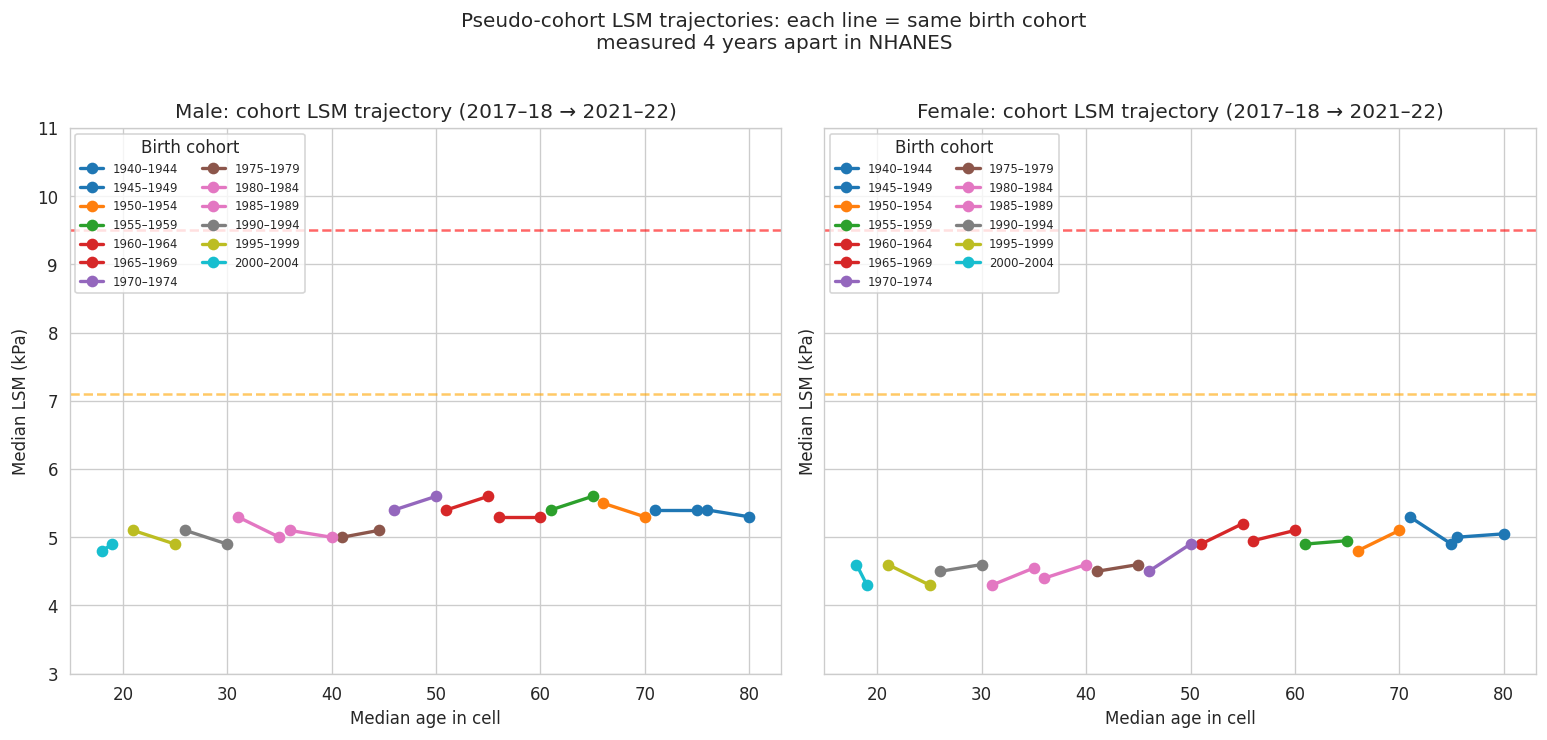

Mean annual LSM change by sex:


,mean,std,count
SEX,,,
Female,-0.0001,0.1065,13
Male,0.0003,0.0522,13


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
cmap = plt.cm.tab10

for ax, sex in zip(axes, ['Male','Female']):
    sub = cohort_lsm[cohort_lsm['SEX']==sex].sort_values(['BIRTH_COHORT','CYCLE'])
    cohorts = sorted(sub['BIRTH_COHORT'].unique())
    for i, bc in enumerate(cohorts):
        cdata = sub[sub['BIRTH_COHORT']==bc].sort_values('CYCLE')
        ax.plot(cdata['age_median'], cdata['lsm_median'], 'o-',
                color=cmap(i/len(cohorts)), label=f'{int(bc)}–{int(bc+4)}',
                markersize=6, lw=2)
    ax.axhline(LSM_F01, color='orange', ls='--', alpha=0.6)
    ax.axhline(LSM_F34, color='red',    ls='--', alpha=0.6)
    ax.set_xlabel('Median age in cell'); ax.set_ylabel('Median LSM (kPa)')
    ax.set_title(f'{sex}: cohort LSM trajectory (2017–18 → 2021–22)')
    ax.legend(title='Birth cohort', fontsize=7, ncol=2, loc='upper left')
    ax.set_ylim(3, 11)

plt.suptitle('Pseudo-cohort LSM trajectories: each line = same birth cohort\n'
             'measured 4 years apart in NHANES', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print('Mean annual LSM change by sex:')
display(piv.groupby('SEX')['annual_lsm_change'].agg(['mean','std','count']).round(4))

## 5. FIB-4 vs LSM concordance

NHANES 2017–18 and 2021–22 both have FIB-4 components and LSM, so we can assess
how well FIB-4 tracks LSM and where they diverge — important for deciding whether
the pseudo-cohort FIB-4 slopes from notebook 01 are a useful proxy for LSM progression.

In [9]:
conc = df_lsm[df_lsm['FIB4'].notna() & df_lsm['LSM_KPA'].notna()].copy()
conc['FIB4_CAT'] = pd.cut(conc['FIB4'], bins=[0, FIB4_LOW, FIB4_HIGH, np.inf],
                            labels=['Low (<1.30)','Interm (1.30–2.67)','High (>2.67)'])

print(f'Subjects with both FIB-4 and LSM: {len(conc):,}')

# Concordance table
ct = pd.crosstab(conc['FIB4_CAT'], conc['LSM_CAT'], margins=True,
                 normalize='index').round(3) * 100
print('\nRow %: FIB-4 category → LSM category')
display(ct)

Subjects with both FIB-4 and LSM: 7,507

Row %: FIB-4 category → LSM category


LSM_CAT,Low F0-F1 (<7.1),Intermediate (7.1-9.4),High F3-F4 (≥9.5)
FIB4_CAT,,,
Low (<1.30),84.1,9.0,6.9
Interm (1.30–2.67),81.1,9.2,9.7
High (>2.67),58.1,13.1,28.9
All,81.9,9.2,8.9


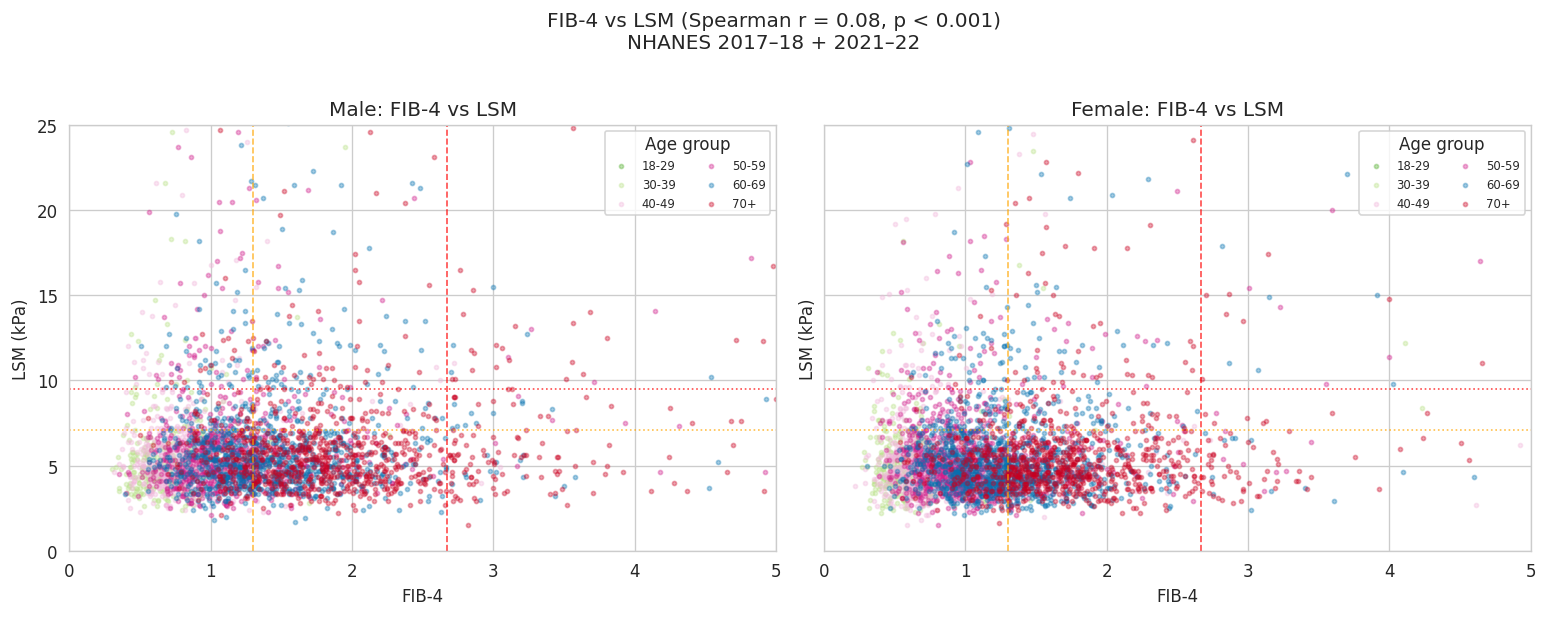

In [10]:
# Scatter: FIB-4 vs LSM coloured by age group
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

age_palette = {'18-29':'#4dac26','30-39':'#b8e186','40-49':'#f1b6da',
               '50-59':'#d01c8b','60-69':'#0571b0','70+':'#ca0020'}

for ax, sex in zip(axes, ['Male','Female']):
    sub = conc[conc['SEX']==sex]
    for ag, color in age_palette.items():
        pts = sub[sub['AGE_GROUP']==ag]
        ax.scatter(pts['FIB4'], pts['LSM_KPA'], s=6, alpha=0.35,
                   color=color, label=ag, rasterized=True)
    ax.axvline(FIB4_LOW,  color='orange', ls='--', lw=1, alpha=0.7)
    ax.axvline(FIB4_HIGH, color='red',    ls='--', lw=1, alpha=0.7)
    ax.axhline(LSM_F01,   color='orange', ls=':',  lw=1, alpha=0.7)
    ax.axhline(LSM_F34,   color='red',    ls=':',  lw=1, alpha=0.7)
    ax.set_xlim(0, 5); ax.set_ylim(0, 25)
    ax.set_xlabel('FIB-4'); ax.set_ylabel('LSM (kPa)')
    ax.set_title(f'{sex}: FIB-4 vs LSM')
    ax.legend(title='Age group', fontsize=7, ncol=2)

r, p = stats.spearmanr(conc['FIB4'].dropna(), conc.loc[conc['FIB4'].notna(),'LSM_KPA'])
plt.suptitle(f'FIB-4 vs LSM (Spearman r = {r:.2f}, p < 0.001)\nNHANES 2017–18 + 2021–22',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Spearman r by age group
print('Spearman r(FIB-4, LSM) by age group:')
rows = []
for ag in age_order:
    sub = conc[conc['AGE_GROUP']==ag][['FIB4','LSM_KPA']].dropna()
    if len(sub) < 10:
        continue
    r, p = stats.spearmanr(sub['FIB4'], sub['LSM_KPA'])
    rows.append({'age_group': ag, 'n': len(sub), 'spearman_r': round(r,3), 'p': round(p,4)})
display(pd.DataFrame(rows))

Spearman r(FIB-4, LSM) by age group:


,age_group,n,spearman_r,p
0,30-39,700,0.067,0.0757
1,40-49,1337,-0.018,0.5038
2,50-59,1572,0.042,0.0972
3,60-69,2143,0.043,0.0484
4,70+,1755,0.039,0.1042


## 6. Steatosis (CAP) and its relationship to LSM

CAP (Controlled Attenuation Parameter, dB/m) is the FibroScan measure of hepatic steatosis.
Steatosis drives NASH, which in turn drives faster fibrosis progression.
Understanding the CAP–LSM relationship by demographics helps parameterise the
NAFL→NASH→fibrosis pathway in a simulation.

In [12]:
cap_valid = df_lsm[df_lsm['CAP_DBM'].notna() & df_lsm['LSM_KPA'].notna()].copy()

# CAP thresholds (Siddiqui 2018): S0 <248, S1 248-267, S2 268-279, S3 ≥280
cap_valid['STEATOSIS_CAT'] = pd.cut(
    cap_valid['CAP_DBM'],
    bins=[0, 248, 268, 280, 500],
    labels=['S0 <11%','S1 11-33%','S2 34-66%','S3 >66%']
)

print('CAP steatosis categories:')
display(cap_valid['STEATOSIS_CAT'].value_counts().sort_index())

print('\nMedian LSM by steatosis category, age group, and sex:')
tbl2 = cap_valid.groupby(['AGE_GROUP','SEX','STEATOSIS_CAT'])['LSM_KPA'].agg(
    ['median','count']
).round(2)
display(tbl2)

CAP steatosis categories:


STEATOSIS_CAT
S0 <11%      4757
S1 11-33%    1198
S2 34-66%     763
S3 >66%      4058
Name: count, dtype: int64


Median LSM by steatosis category, age group, and sex:


median  count
AGE_GROUP SEX    STEATOSIS_CAT               
18-29     Female S0 <11%          4.30    626
                 S1 11-33%        4.60     73
                 S2 34-66%        4.70     40
                 S3 >66%          5.30    174
          Male   S0 <11%          4.70    544
                 S1 11-33%        5.20     87
                 S2 34-66%        4.60     49
                 S3 >66%          5.60    231
30-39     Female S0 <11%          4.10    447
                 S1 11-33%        4.30    109
                 S2 34-66%        4.50     57
                 S3 >66%          5.60    220
          Male   S0 <11%          4.60    337
                 S1 11-33%        4.80     63
                 S2 34-66%        5.00     45
                 S3 >66%          5.70    287
40-49     Female S0 <11%          4.30    363
                 S1 11-33%        4.50     90
                 S2 34-66%        4.50     49
                 S3 >66%          5.50    274
          Male   S0 <11%          4.50    235
                 S1 11-33%        4.90     73
                 S2 34-66%        5.00     45
                 S3 >66%          6.00    318
50-59     Female S0 <11%          4.50    347
                 S1 11-33%        4.90    109
                 S2 34-66%        5.15     70
                 S3 >66%          5.80    386
          Male   S0 <11%          4.65    232
                 S1 11-33%        4.80     73
                 S2 34-66%        5.30     70
                 S3 >66%          6.10    403
60-69     Female S0 <11%          4.40    437
                 S1 11-33%        4.80    155
                 S2 34-66%        4.65    110
                 S3 >66%          5.70    533
          Male   S0 <11%          4.90    385
                 S1 11-33%        5.20    152
                 S2 34-66%        5.15     74
                 S3 >66%          6.00    489
70+       Female S0 <11%          4.60    448
                 S1 11-33%        4.80    125
                 S2 34-66%        5.15     82
                 S3 >66%          5.60    330
          Male   S0 <11%          4.90    356
                 S1 11-33%        5.30     89
                 S2 34-66%        5.35     72
                 S3 >66%          6.00    413

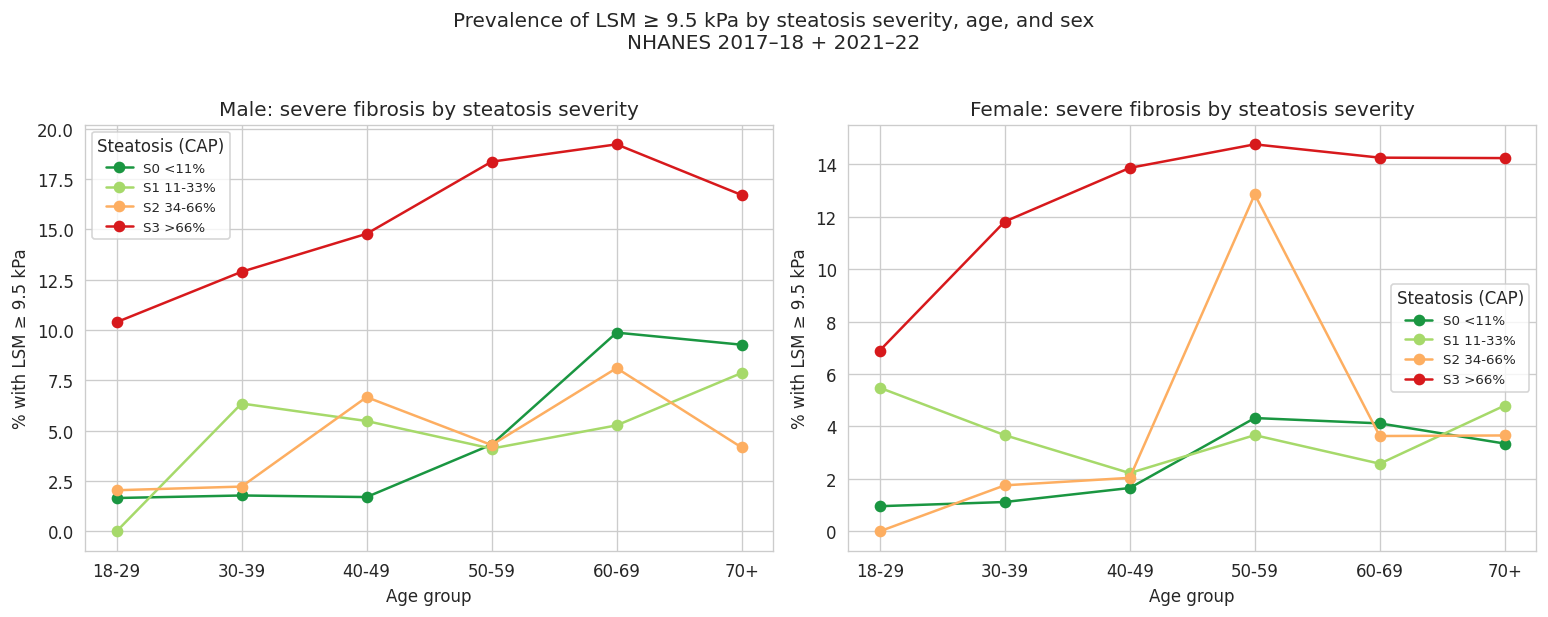

In [13]:
# Proportion with LSM ≥ 9.5 kPa by steatosis category
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
steat_order = ['S0 <11%','S1 11-33%','S2 34-66%','S3 >66%']
steat_colors = ['#1a9641','#a6d96a','#fdae61','#d7191c']

for ax, sex in zip(axes, ['Male','Female']):
    sub = cap_valid[cap_valid['SEX']==sex]
    by_age_steat = sub.groupby(['AGE_GROUP','STEATOSIS_CAT']).apply(
        lambda g: (g['LSM_KPA'] >= LSM_F34).mean() * 100
    ).reset_index(name='pct_F34')
    for j, (sc, col) in enumerate(zip(steat_order, steat_colors)):
        d = by_age_steat[by_age_steat['STEATOSIS_CAT']==sc]
        d = d.set_index('AGE_GROUP').reindex(age_order).reset_index()
        ax.plot(range(len(age_order)), d['pct_F34'], 'o-', color=col, label=sc)
    ax.set_xticks(range(len(age_order))); ax.set_xticklabels(age_order)
    ax.set_xlabel('Age group'); ax.set_ylabel('% with LSM ≥ 9.5 kPa')
    ax.set_title(f'{sex}: severe fibrosis by steatosis severity')
    ax.legend(title='Steatosis (CAP)', fontsize=8)

plt.suptitle('Prevalence of LSM ≥ 9.5 kPa by steatosis severity, age, and sex\n'
             'NHANES 2017–18 + 2021–22', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 7. Summary: simulation parameter estimates from NHANES LSM data

Cross-sectional and pseudo-cohort estimates for use in microsimulation.

In [14]:
# Key summary statistics for simulation
print('=== LSM prevalence by age and sex (both cycles combined) ===')
lsm_prev = df_lsm.groupby(['AGE_GROUP','SEX']).apply(
    lambda g: pd.Series({
        'n':                len(g),
        'median_lsm':       g['LSM_KPA'].median(),
        'pct_F01':          (g['LSM_KPA'] < LSM_F01).mean() * 100,
        'pct_interm':       ((g['LSM_KPA'] >= LSM_F01) & (g['LSM_KPA'] < LSM_F34)).mean() * 100,
        'pct_F34':          (g['LSM_KPA'] >= LSM_F34).mean() * 100,
    })
).reset_index()
display(lsm_prev.round(1))

print('\n=== Pseudo-cohort annual LSM change by sex ===')
display(piv.groupby('SEX')[['delta_lsm_4yr','annual_lsm_change']]
        .agg(['mean','std']).round(4))

# Save tables
lsm_prev.to_csv('outputs/lsm_prevalence_by_age_sex.csv', index=False)
piv.to_csv('outputs/lsm_pseudo_cohort_4yr_change.csv', index=False)
prev_lsm.to_csv('outputs/lsm_prevalence_by_age_sex_race.csv', index=False)
print('\nCSV tables saved to outputs/')

=== LSM prevalence by age and sex (both cycles combined) ===


,AGE_GROUP,SEX,n,median_lsm,pct_F01,pct_interm,pct_F34
0,18-29,Female,913.0,4.5,94.1,3.5,2.4
1,18-29,Male,912.0,5.0,88.7,7.6,3.7
2,30-39,Female,834.0,4.4,89.1,6.6,4.3
3,30-39,Male,732.0,5.1,85.4,8.1,6.6
4,40-49,Female,776.0,4.6,86.5,7.5,6.1
5,40-49,Male,671.0,5.1,81.5,9.8,8.6
6,50-59,Female,912.0,5.1,80.0,10.6,9.3
7,50-59,Male,778.0,5.4,77.4,11.1,11.6
8,60-69,Female,1235.0,4.9,81.6,10.1,8.3
9,60-69,Male,1100.0,5.4,76.5,10.3,13.3



=== Pseudo-cohort annual LSM change by sex ===


delta_lsm_4yr         annual_lsm_change        
                mean     std              mean     std
SEX                                                   
Female        0.0692  0.2529           -0.0001  0.1065
Male         -0.0231  0.1739            0.0003  0.0522


CSV tables saved to outputs/


---
## 8. What EPIC Cosmos could add

**EPIC Cosmos** is a de-identified EHR database from ~300 health systems (~280 million
patient records as of 2025). Unlike NHANES, it is:
- **Longitudinal within patients** — the same patient may appear in multiple encounters,
  years apart, allowing true individual-level FIB-4 trajectories
- **Much larger** — enables rare subgroup analyses (e.g., specific race × age × comorbidity cells)
- **Linked to billing codes** — cirrhosis, HCC, transplant, and death endpoints available

### Specific analyses Cosmos enables that NHANES cannot

| Analysis | Why NHANES falls short | What Cosmos adds |
|----------|----------------------|------------------|
| **True individual FIB-4 trajectories** | NHANES is one exam per person | Repeated labs (AST, ALT, platelets) across years → FIB-4 at each encounter |
| **Age/sex/race × comorbidity-specific progression** | Too few people per cell for rare subgroups | Millions of patients allow stratification by DM, obesity, alcohol use, etc. |
| **Transition probabilities between FIB-4 categories** | Not measurable from single exam | Can estimate P(low→interm), P(interm→high), P(regression) per year by demographics |
| **Time from elevated FIB-4 to hard endpoints** | NHANES mortality linkage limited to 2019 | ICD codes for cirrhosis (K74.x), HCC (C22.0), LT (Z94.4) in Cosmos |
| **FIB-4 in people with competing conditions** | NHANES excludes institutionalised persons | Cosmos includes hospital-based patients with comorbidities |
| **Secular trends by race** | Too few cycles with LSM | Calendar-year trends 2010–2025 |

### Data elements to request from Cosmos

For a fibrosis progression simulation, the ideal Cosmos query would pull:

```
- Patient demographics: birth_year, sex, race/ethnicity
- All AST, ALT, platelet lab results with encounter dates
  (LOINC: AST=1920-8, ALT=1742-6, PLT=777-3)
- BMI at each encounter
- ICD-10 diagnoses: K70-K77 (liver disease), E11 (T2D), E66 (obesity)
- Outcome codes: K74.x (fibrosis/cirrhosis), C22.0 (HCC), Z94.4 (liver transplant)
- Procedure codes: 47135/47136 (liver transplant), 0DY00Z0/1 (transplant)
```

From this you can compute FIB-4 at each eligible lab encounter (when AST, ALT, PLT drawn
within 30 days of each other) and then model the annual change in FIB-4 as a function of
age, sex, race, BMI, and DM status using a linear mixed model or Markov transition framework.

### Limitations of Cosmos to anticipate

- **Selection bias**: only patients who sought care — sicker than general population.
  Fibrosis progression rates may be higher than NHANES population estimates.
- **Lab measurement variation**: AST/ALT assay methods vary by site and era; FIB-4 calculated
  from EHR labs may differ systematically from standardised NHANES measurements.
- **No LSM**: Cosmos does not include FibroScan readings; fibrosis staging relies entirely
  on FIB-4 / APRI or ICD codes — the same limitation as the NHANES FIB-4 pseudo-cohort.
- **Inconsistent follow-up**: patients may switch health systems, causing right-censoring
  that is not at random.

### Recommended Cosmos analysis plan

1. **Cohort definition**: adults ≥ 35 with ≥ 2 FIB-4-eligible lab encounters ≥ 1 year apart
2. **Exposure**: baseline FIB-4 category and demographics
3. **Outcome**: FIB-4 category at each subsequent encounter (Markov transitions)
4. **Model**: multinomial logistic regression or multistate survival model:
   - States: Low / Intermediate / High / Cirrhosis (ICD K74) / Death
   - Covariates: age at baseline, sex, race/ethnicity, BMI, DM, alcohol use disorder
5. **Validation**: compare predicted FIB-4 distributions to NHANES cross-sectional
   distributions at matching ages — if the Cosmos-trained model, when applied to a simulated
   population starting from NHANES baseline FIB-4 distributions, reproduces the observed
   NHANES age-FIB-4 curves, the progression rates are plausible.

This Cosmos-trained Markov model would be a substantial improvement over the NHANES
pseudo-cohort approach and could be the core engine of a fibrosis progression simulation.